Landfall events meeting time criteria: 464
Number of MJO active dates: 14550
Landfall events matched to MJO active days: 258

Landfall events by region:
South China    176
East China      67
North China     15
Name: region, dtype: int64


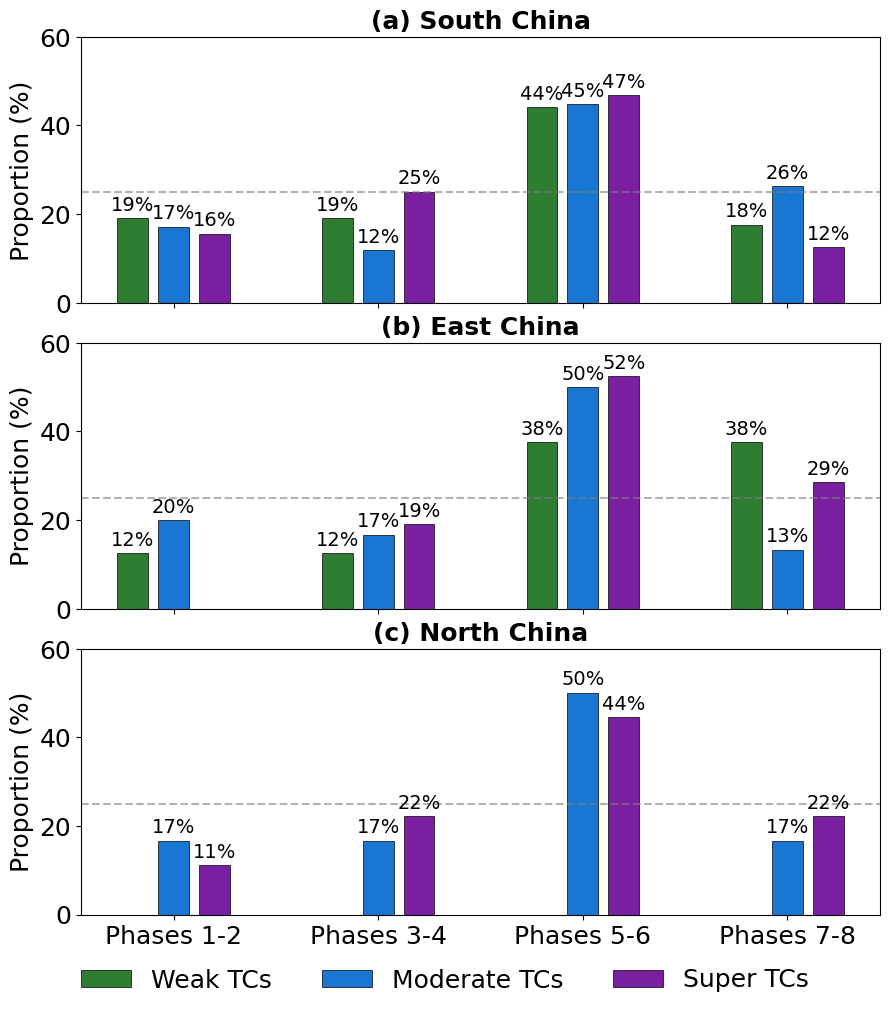

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ==================== Global path configuration ====================
INFO_PATH = "./typhoon_output/landfall_typhoons_info.csv"
MJO_PATH = "./ERA5 MJO (1950-2024).csv"

# ==================== Typhoon intensity category mapping ====================
CATEGORY_MAP = {1: 'Weak TCs', 2: 'Moderate TCs', 3: 'Super TCs'}

COLOR_MAP = {'Weak TCs': '#2E7D32', 'Moderate TCs': '#1976D2', 'Super TCs': '#7B1FA2'}

# ==================== MJO phase grouping ====================
def phase_to_group(phase):
    if pd.isna(phase):
        return None
    p = int(phase)
    if p in [1, 2]:
        return 'Phases 1-2'
    elif p in [3, 4]:
        return 'Phases 3-4'
    elif p in [5, 6]:
        return 'Phases 5-6'
    elif p in [7, 8]:
        return 'Phases 7-8'
    else:
        return None

GROUP_ORDER = ['Phases 1-2', 'Phases 3-4', 'Phases 5-6', 'Phases 7-8']

# ==================== Region division ====================
def region_from_lat(lat):
    """Return region name based on latitude"""
    if lat < 24:
        return 'South China'
    elif lat <= 34:
        return 'East China'
    else:
        return 'North China'

REGIONS = ['South China', 'East China', 'North China']

# ==================== 1. Load and filter typhoon landfall information ====================
info_df = pd.read_csv(INFO_PATH)
info_df['code_str'] = info_df['chinese_code'].apply(lambda x: f"{x:04d}")
info_df['landfall_time'] = pd.to_datetime(info_df['landfall_time'])
info_df['landfall_date'] = info_df['landfall_time'].dt.date
info_df['year'] = info_df['landfall_time'].dt.year
info_df['month'] = info_df['landfall_time'].dt.month

# Filter: 1960–2024, June–October
mask = (info_df['year'] >= 1960) & (info_df['year'] <= 2024) & (info_df['month'].between(6, 10))
info_df = info_df[mask].copy()
print(f"Landfall events meeting time criteria: {len(info_df)}")

# Keep necessary fields, use max_wind_category for typhoon intensity classification
info_clean = info_df[['code_str', 'name', 'landfall_date', 'landfall_lat', 'landfall_lon',
                      'landfall_wind_speed', 'max_wind_category']].copy()
info_clean.rename(columns={'max_wind_category': 'typhoon_category'}, inplace=True)

# Add region column
info_clean['region'] = info_clean['landfall_lat'].apply(region_from_lat)

# ==================== 2. Load and filter MJO data ====================
mjo_df = pd.read_csv(MJO_PATH)
mjo_df['date'] = pd.to_datetime(mjo_df['date']).dt.date

# Time range 1960–2024
mjo_df = mjo_df[(mjo_df['date'] >= pd.to_datetime('1960-01-01').date()) &
                (mjo_df['date'] <= pd.to_datetime('2024-12-31').date())]

# Keep only active events with amplitude ≥ 1
mjo_df = mjo_df[mjo_df['amplitude'] >= 1].copy()
mjo_df['phase_group'] = mjo_df['phase'].apply(phase_to_group)
mjo_df = mjo_df.dropna(subset=['phase_group'])

# Build dictionary: date → phase group
date_to_phase = pd.Series(mjo_df['phase_group'].values, index=mjo_df['date']).to_dict()
print(f"Number of MJO active dates: {len(date_to_phase)}")

# ==================== 3. Match landfall dates with MJO ====================
info_clean['phase_group'] = info_clean['landfall_date'].map(date_to_phase)
info_clean = info_clean.dropna(subset=['phase_group'])
print(f"Landfall events matched to MJO active days: {len(info_clean)}")

# Check event counts by region
print("\nLandfall events by region:")
print(info_clean['region'].value_counts())

# ==================== 4. Statistics by region ====================
region_stats = {}
for region in REGIONS:
    region_data = info_clean[info_clean['region'] == region]
    # Group count by typhoon category and phase group
    counts = region_data.groupby(['typhoon_category', 'phase_group']).size().unstack(fill_value=0)
    counts = counts.reindex(columns=GROUP_ORDER, fill_value=0)   # ensure all phase groups present
    region_stats[region] = counts

# ==================== 5. Calculate percentages ====================
region_percentages = {}
for region, counts in region_stats.items():
    # For each typhoon category (row) compute percentage
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    region_percentages[region] = percentages

# ==================== 6. Plot: three vertically stacked subplots ====================
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True, sharey=True)
# fig.suptitle('Proportion of Typhoon Landfall Days by MJO Phase and Category in Coastal Regions',
#              fontsize=14, fontweight='bold')
itit = ["(a) ", "(b) ", "(c) "]
# Plotting parameters
x = np.arange(len(GROUP_ORDER))          # phase group positions (0,1,2,3)
width = 0.15                             # bar width
gap = 0.05                               # within-group gap
offsets = [-width - gap, 0, width + gap] # offsets for the three typhoon categories

for ax, region, it in zip(axes, REGIONS, itit):
    percentages = region_percentages[region]
    categories = [1, 2, 3]              # Storms, TCs, Super TCs

    # Collect all bar heights to set y-axis limit
    all_heights = []
    # Add 25% dashed reference line
    ax.axhline(y=25, color='gray', alpha=0.6, linestyle='--', linewidth=1.5, label='_nolegend_')

    for i, cat in enumerate(categories):
        cat_name = CATEGORY_MAP[cat]
        if cat in percentages.index:
            pct_vals = percentages.loc[cat].values
        else:
            pct_vals = np.zeros(len(GROUP_ORDER))
        all_heights.extend(pct_vals)

        # Bar positions
        bar_positions = x + offsets[i]
        bars = ax.bar(bar_positions, pct_vals, width,
                      color=COLOR_MAP[cat_name],
                      edgecolor='black', linewidth=0.5,
                      label=cat_name)

        # Label percentages (only if > 0.5%)
        for bar, pct in zip(bars, pct_vals):
            if pct > 0.5:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.9,
                        f'{pct:.0f}%', ha='center', va='bottom', fontsize=14)

    # Set x-axis
    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_ORDER, fontsize=18)
    ax.tick_params(axis='y', labelsize=18)         # y-axis tick label fontsize
    ax.set_ylabel('Proportion (%)', fontsize=18)

    # Subplot title (region name)
    ax.set_title(it + region, fontsize=18, fontweight='bold')

    # Set y-axis range
    ax.set_ylim(0, 60)

    # Remove grid lines
    ax.grid(False)

# Add a common legend (below the bottom subplot)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # remove duplicates
fig.legend(by_label.values(), ['Weak TCs', 'Moderate TCs', 'Super TCs'],
           loc='lower center',
           ncol=3, fontsize=18, frameon=False,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(hspace=0.15, bottom=0.08)
plt.savefig('3all.png', dpi=600, bbox_inches='tight')
plt.show()